# Building a training sample, step by step

This notebook builds **one** `streamgoggles` training sample two ways:

1. **Step by step** — every stage of the pipeline as its own cell, so you can
   see (and plot) what each stage actually produces: study region -> cached
   background -> realized stream -> placed in the footprint -> injected
   through the survey model -> cuts/clipping -> window -> matched-filter
   selection -> combined/finalized/cropped maps -> rasterized label -> `Sample`.
2. **Minimal command** — the same result via the real pipeline API
   (`StreamInjector.inject_single_stream` / `inject_background_only`), which
   is what `scripts/train.py` (or any dataset loader) actually calls.

All the tunable settings live in **one cell (§1)** as plain dictionaries —
change them and re-run from there to explore a different background source,
richness unit, label policy, pixelization, etc.

Everything here runs against the real `streamobs`/`ugali` machinery (no
mocking), using the `light` synthetic LSST yr1 background by default so it
needs no large data files.

In [1]:
import dataclasses
import tempfile

import healpy as hp
import matplotlib.pyplot as plt
import numpy as np

from streamgoggles.background import Background, build_raw_background_maps
from streamgoggles.background_sources import (
    DataFileBackgroundSource,
    StreamObsCatalogueBackgroundSource,
    StreamObsLightBackgroundSource,
    StudyRegion,
)
from streamgoggles.data_preparation import Cut, apply_cuts, apply_magnitude_clipping
from streamgoggles.injector import (
    StreamInjector,
    inject_background_only,
    place_stream_in_footprint,
    resolve_richness_to_nstars,
)
from streamgoggles.matched_filter import (
    PixelizationSpec,
    StreamobsSplineFilter,
    combine_full_maps,
    crop_window,
    finalize_full,
    make_raw_map,
)
from streamgoggles.rasterize import rasterize
from streamgoggles.sample import Sample
from streamgoggles.storage import BackgroundMapStore
from streamgoggles.stream_sources import StreamObsSource
from streamgoggles.windows import sample_random_window, sample_stream_window
from streamobs.columns import flag_col
from streamobs.observed import StreamInjector as ObsStreamInjector

%matplotlib inline

## 1. Configuration — edit these, then re-run from §2 on

These mirror the shapes of `config/background.yaml`, `config/matched_filter.yaml`
and `config/streams/injection_grid.yaml` (see PLAN.md), just as plain dicts
here so you can tweak a value and immediately see its effect, without
round-tripping through YAML.

`stream_cfg["richness"]` takes exactly one of `nstars` / `mass` (Msun) /
`surface_brightness` (mag/arcsec^2) — whichever you set is converted to a
true star count by `resolve_richness_to_nstars` in §2.4 (decision 16/§4.1).

`cuts_cfg`/`clipping_cfg` are their **own** top-level dicts, not nested
inside `background_cfg` — they're shared, catalog-agnostic settings
(`data_preparation.apply_cuts`/`apply_magnitude_clipping`, decision 13),
applied identically to the background catalog (§2.3) *and* the injected
stream catalog (§2.6). Nesting them under `background_cfg` would suggest
they're background-specific, which is exactly backwards: they're what makes
selection consistent between background and stream in the first place — the
same reason `Cut`/`apply_cuts`/`apply_magnitude_clipping` live in
`data_preparation.py` rather than `background.py`.

**Found while building this notebook:** `config/background.yaml`'s own
default cuts (`quantity: snr`) don't actually work with its own default
`source: light` — the `light` generator doesn't produce per-star error
columns at all (only `injection`/`data_file` do), so an "snr" cut has no
column to read (`KeyError`). Flagged for a real fix to `background.yaml`
separately; the cuts below use `"mag"` instead, which every source produces.

In [2]:
SEED = 42

study_region_cfg = dict(center_ra=0.0, center_dec=-30.0, width_deg=25.0, height_deg=18.0)

# Shared, catalog-agnostic (decision 13) -- applied identically to the
# background (§2.3) and the injected stream (§2.6), not background-specific.
cuts_cfg = [
    # "snr" cuts need per-star error columns, which only "injection"/
    # "data_file" background sources produce -- not "light" (see note above);
    # the injected stream always has them, since streamobs's own injector
    # always reports one.
    dict(quantity="mag", band="g", op="<", value=26.5),
    dict(quantity="mag", band="r", op="<", value=26.0),
]
clipping_cfg = {"g": {"min": 16.0, "max": 26.5}, "r": {"min": 16.0, "max": 26.0}}

background_cfg = dict(
    source="light",       # "data_file" | "light" | "injection"
    survey="lsst",
    release="yr1",         # "yr1" (synthetic forecast) or "dp2" (real skim, data_file only)
    source_kwargs={},      # extra kwargs for the chosen BackgroundSource.load()
    finalize={"enabled": False},  # background-subtraction not implemented yet (matched_filter.finalize_full)
)

matched_filter_cfg = dict(
    reference_isochrone=dict(age=12.5, z=0.0002),
    bands=["g", "r"],
    pixelization=dict(nside=64, image_size_pix=(41, 41), pixel_scale_deg=1.0),
    distance_moduli=[16.0, 16.8, 17.5],  # trial distances scanned; 16.8 matches the stream below
)

stream_cfg = dict(
    morphology="uniform",       # "uniform" | "spline" (decision 5)
    richness={"surface_brightness": 30.0},  # or {"mass": 5000.0} or {"surface_brightness": 30.0} or {"nstars": 3000}
    width=0.2,
    length=8.0,
    distance_modulus=16.8,
    age=12.5,
    z=0.0002,
)

label_cfg = dict(
    policy="density",          # "binary" | "density" | "soft_distance" (stub)
    normalization="max",       # density only
    smooth_sigma_deg=None,     # density only
    dilate_to_width=True,      # binary only
)

window_cfg = dict(min_stream_length_deg=5.0, max_attempts=100)  # decision 21

namespace = f"{background_cfg['survey']}_{background_cfg['release']}"
rng = np.random.default_rng(SEED)

## 2. Step by step

### 2.1 Study region — where synthetic background may be generated at all

A plain RA/Dec box (decision 24), independent of and larger than any one
sample's window.

In [3]:
study_region = StudyRegion(**study_region_cfg)
study_region

StudyRegion(center_ra=0.0, center_dec=-30.0, width_deg=25.0, height_deg=18.0)

### 2.2 Pixelization and matched filter

`PixelizationSpec` fixes the HEALPix `nside` (and auto-derives `pixel_scale_deg`
if you don't set one — see `matched_filter_demo.ipynb` for that in detail).
The matched filter is a hard color-magnitude cut around a reference isochrone
(age, metallicity), evaluated at a trial distance modulus.

In [4]:
pix = PixelizationSpec(**matched_filter_cfg["pixelization"])
matched_filter = StreamobsSplineFilter(
    iso_config=matched_filter_cfg["reference_isochrone"], namespace=namespace
)
pix

PixelizationSpec(nside=64, center_ra=0.0, center_dec=0.0, rotation_deg=0.0, image_size_pix=(41, 41), pixel_scale_deg=1.0, projection='gnomonic', interpolate=True, nest=False)

### 2.3 Background: load, cut, clip, cache the raw maps

`Background.load_or_cache` does four things in one call: pick the
`BackgroundSource` for `background_cfg["source"]`, load its catalog
(restricted to `study_region` for the synthetic sources), apply the *same*
cuts/clipping the stream will get in §2.6, and — for every distance in
`matched_filter_cfg["distance_moduli"]` — run the matched filter **once**
and cache the resulting raw HEALPix count map (`BackgroundMapStore`, here a
throwaway temp directory so this demo never touches `data/background_maps/`).

This is the *only* place the matched filter ever touches the background —
every stream injected below (however many) reuses these cached maps rather
than re-running `select()` on the background catalog.

In [5]:
source_classes = {
    "data_file": DataFileBackgroundSource,
    "light": StreamObsLightBackgroundSource,
    "injection": StreamObsCatalogueBackgroundSource,
}
background_source = source_classes[background_cfg["source"]]()
cuts = [Cut(**c) for c in cuts_cfg]

store = BackgroundMapStore(tempfile.mkdtemp(prefix="streamgoggles_demo_bgmaps_"))

background = Background.load_or_cache(
    source=background_source,
    source_cfg=background_cfg["source_kwargs"],
    study_region=study_region,
    cuts=cuts,
    clipping=clipping_cfg,
    matched_filter=matched_filter,
    bands=matched_filter_cfg["bands"],
    distance_moduli=matched_filter_cfg["distance_moduli"],
    finalize_cfg=background_cfg["finalize"],
    store=store,
    pix=pix,
    survey=background_cfg["survey"],
    release=background_cfg["release"],
    filter_config=matched_filter_cfg["reference_isochrone"],
)
print(f"background catalog: {len(background.catalog)} stars (after cuts+clipping)")
print(f"footprint: {background.footprint.sum()} / {len(background.footprint)} HEALPix pixels valid")

Loading survey data for 'lsst_yr1'...
  Loading config from: lsst_yr1.yaml

LOADING SURVEY DATA FILES
Survey data directory: /Users/pelissier/Documents/Codes/packages/streamobs/streamobs/../data/surveys/lsst_yr1

Fallback directory for shared data files: /Users/pelissier/Documents/Codes/packages/streamobs/streamobs/../data/others

Available bands: g, i, r, u, y, z


Loading survey properties...
Loading magnitude limit maps...
  ✓ Success for g-band magnitude limit
  ⚠ Warning: 'maglim_map_i' not specified in config (skipping i-band)
  ✓ Success for r-band magnitude limit
  ⚠ Warning: 'maglim_map_u' not specified in config (skipping u-band)
  ⚠ Warning: 'maglim_map_y' not specified in config (skipping y-band)
  ⚠ Warning: 'maglim_map_z' not specified in config (skipping z-band)

Loading completeness/efficiency function...
  Loading Completeness/efficiency function...
    File: lsst_dc2_stellar_efficiency_cutr.csv
    ✓ Success
  Loading Detection efficiency function...
    File: lsst_dc

/Users/pelissier/Documents/Codes/packages/streamobs/streamobs/background/background.py:159: UserWarning: Requested nside=4096 exceeds the magnitude-limit map resolution (nside=128). Capping to nside=128.
  return gen.generate(


background catalog: 6398187 stars (after cuts+clipping)
footprint: 601 / 49152 HEALPix pixels valid


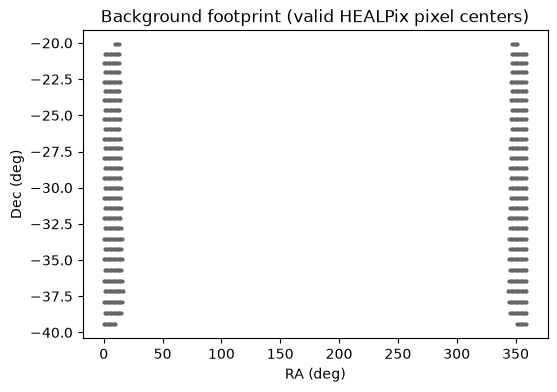

In [6]:
fp_ra, fp_dec = hp.pix2ang(pix.nside, np.flatnonzero(background.footprint), lonlat=True)
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(fp_ra, fp_dec, s=4, color="0.4")
ax.set_xlabel("RA (deg)")
ax.set_ylabel("Dec (deg)")
ax.set_title("Background footprint (valid HEALPix pixel centers)")
plt.show()

### 2.4 Realize the stream — richness resolved to a true star count

`resolve_richness_to_nstars` converts whichever unit `stream_cfg["richness"]`
is expressed in (nstars / mass / surface_brightness) to an integer `nstars`,
using `inject_utils`'s conversions. The stream is then realized in its own
`phi1`/`phi2` frame with TRUE (noiseless) magnitudes — nothing about the sky
or survey yet.

In [7]:
richness_kind, richness_value = next(iter(stream_cfg["richness"].items()))
stream_params = {k: v for k, v in stream_cfg.items() if k != "richness"}
stream_params["richness"] = richness_value
stream_params = resolve_richness_to_nstars(stream_params, richness_kind)
print(f"richness_kind={richness_kind!r}, value={richness_value} -> nstars={stream_params['nstars']}")

stream_df = StreamObsSource().realize(stream_params, rng)
stream_df.head()

richness_kind='surface_brightness', value=30.0 -> nstars=178331


,phi1,phi2,dist,is_stream,lsst_g_true,lsst_r_true
0,2.191648,0.038032,16.8,True,25.105640,24.401095
1,-0.488972,-0.044475,16.8,True,27.768083,26.725205
2,2.868783,-0.001792,16.8,True,26.646945,25.730404
3,1.578944,0.010164,16.8,True,26.272335,25.401006
4,-3.246581,0.176728,16.8,True,28.487723,27.357877


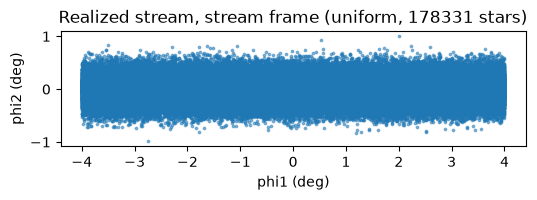

In [8]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.scatter(stream_df["phi1"], stream_df["phi2"], s=3, alpha=0.5)
ax.set_xlabel("phi1 (deg)")
ax.set_ylabel("phi2 (deg)")
ax.set_title(f"Realized stream, stream frame ({stream_params['morphology']}, {len(stream_df)} stars)")
ax.set_aspect("equal")
plt.show()

### 2.5 Place the stream in the footprint

Picks a random valid footprint pixel + random position angle and builds a
great-circle frame there (decision: not streamobs's own `_find_gc_frame`
rejection search, which fails against a footprint this narrow — see
`injector.py`'s `place_stream_in_footprint` docstring), giving every star a
real `ra`/`dec`.

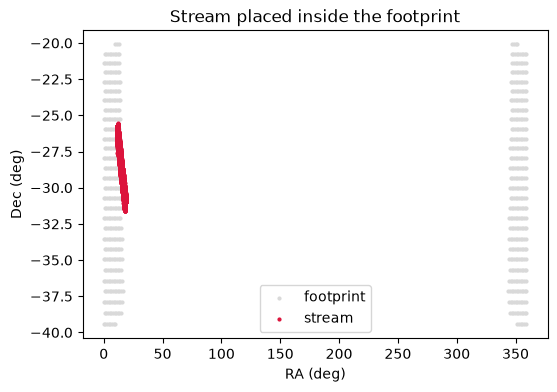

In [9]:
placed_df = place_stream_in_footprint(stream_df, background.footprint, pix.nside, rng)

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(fp_ra, fp_dec, s=4, color="0.85", label="footprint")
ax.scatter(placed_df["ra"], placed_df["dec"], s=4, color="crimson", label="stream")
ax.set_xlabel("RA (deg)")
ax.set_ylabel("Dec (deg)")
ax.legend()
ax.set_title("Stream placed inside the footprint")
plt.show()

### 2.6 Inject through the survey model, then apply the same cuts/clipping as the background

`streamobs.observed.StreamInjector.inject()` adds observed (noisy)
magnitudes, reported errors, and a detection flag — using the *same*
`ra`/`dec` already set in §2.5, since it only fills in columns that are
missing. Undetected stars carry a `"BAD_MAG"` sentinel instead of a number,
so they're filtered out (via the detection flag) before anything downstream
touches those columns numerically. What's left then gets the *identical*
`apply_cuts`/`apply_magnitude_clipping` calls the background got in §2.3
(decision 13) — same function, same config, so selection is consistent
regardless of whether a star is real background or injected stream.

In [10]:
obs_injector = ObsStreamInjector(background_cfg["survey"], release=background_cfg["release"])
injected_df = obs_injector.inject(
    placed_df, bands=matched_filter_cfg["bands"], rng=rng, verbose=False
)
detected = injected_df[injected_df[flag_col(namespace)]].reset_index(drop=True)
print(f"{len(detected)} / {len(injected_df)} stream stars detected by the survey model")

detected = apply_cuts(detected, cuts, namespace=namespace, verbose=False)
if clipping_cfg:
    detected = apply_magnitude_clipping(detected, clipping_cfg, namespace=namespace)
print(f"{len(detected)} stream stars remain after cuts + magnitude clipping")
detected.head()

✓ Using cached survey data for 'lsst_yr1'


ValueError: Survey 'lsst_yr1' has no 'sample' _nocut photo-error curve, which is required for band 'g': it is not the reference band ('r'), so its photometry is forced and must not use the detected-population curve. Add 'log_photo_error_sample_nocut' to the survey config (regenerate the products to emit the *_nocut.csv curves).

### 2.7 Sample a window

Rejection-samples a window (same pixel size as `pix`) with >= 5 deg of
stream track inside it (decision 21) — a floor, not a guarantee of full
inclusion.

In [ ]:
size_deg = pix.image_size_pix[0] * pix.pixel_scale_deg
window = sample_stream_window(
    detected["ra"].to_numpy(dtype=float),
    detected["dec"].to_numpy(dtype=float),
    stream_params.get("width", 0.0),
    background.footprint,
    pix.nside,
    size_deg=size_deg,
    min_stream_length_deg=window_cfg["min_stream_length_deg"],
    max_attempts=window_cfg["max_attempts"],
    rng=rng,
)
window

Window(center_ra=357.6152047852359, center_dec=-36.334907940484, rotation_deg=200.39010223744367, width_deg=41.0, height_deg=41.0)

### 2.8 Per trial distance: select, rasterize to HEALPix, combine, finalize, crop

For each trial distance modulus: the matched filter selects which stream
stars are color-magnitude-consistent with *that* distance, those get their
own raw HEALPix count map, which is added to the background's own
(precomputed once, §2.3) raw map, optionally finalized (identity here —
background subtraction isn't implemented yet, decision 18 default off), and
cropped/projected to the window. The background-only and stream-only panels
below are for illustration; only the combined map is part of the real
pipeline output.

In [ ]:
bg_channels, stream_channels, combined_channels = [], [], []
valid_mask = None

for dm in matched_filter_cfg["distance_moduli"]:
    selected = matched_filter.select(detected, matched_filter_cfg["bands"], dm)
    stream_raw, _ = make_raw_map(detected, selected, pix)
    combined_raw = combine_full_maps(background.raw_map_full_dict[dm], stream_raw, background.valid_mask_full)
    finalized = finalize_full(combined_raw, background.valid_mask_full, background_cfg["finalize"])

    windowed_bg, _ = crop_window(background.raw_map_full_dict[dm], background.valid_mask_full, window, pix)
    windowed_stream, _ = crop_window(stream_raw, background.valid_mask_full, window, pix)
    windowed_combined, windowed_valid = crop_window(finalized, background.valid_mask_full, window, pix)

    bg_channels.append(windowed_bg)
    stream_channels.append(windowed_stream)
    combined_channels.append(windowed_combined)
    if valid_mask is None:
        valid_mask = windowed_valid

map_stack = np.stack(combined_channels, axis=0).astype(np.float32)
print(f"map_stack shape: {map_stack.shape} (n_dist, ny, nx)")

map_stack shape: (3, 41, 41) (n_dist, ny, nx)


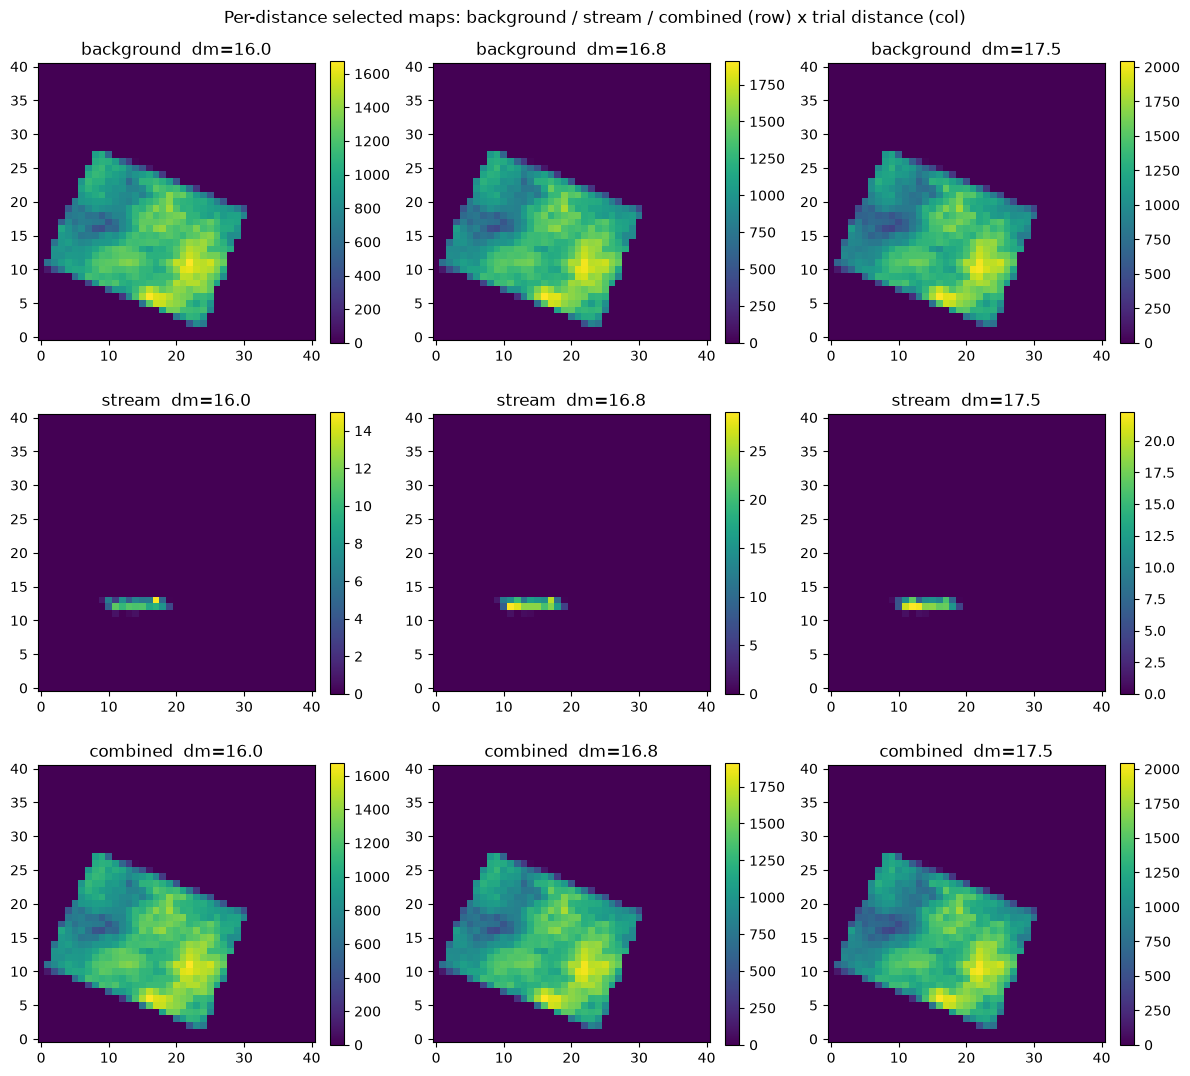

In [ ]:
n_dist = len(matched_filter_cfg["distance_moduli"])
fig, axes = plt.subplots(3, n_dist, figsize=(4 * n_dist, 11), squeeze=False)
for j, dm in enumerate(matched_filter_cfg["distance_moduli"]):
    for i, (channels, label) in enumerate(
        [(bg_channels, "background"), (stream_channels, "stream"), (combined_channels, "combined")]
    ):
        ax = axes[i, j]
        im = ax.imshow(channels[j], origin="lower", cmap="viridis")
        ax.set_title(f"{label}  dm={dm}")
        plt.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle("Per-distance selected maps: background / stream / combined (row) x trial distance (col)")
plt.tight_layout()
plt.show()

### 2.9 Rasterize the label

The label doesn't depend on distance modulus for `"binary"`/`"density"` (only
the still-stubbed `"soft_distance"` policy does), so this produces a single
2D image that gets broadcast to every `map_stack` channel.

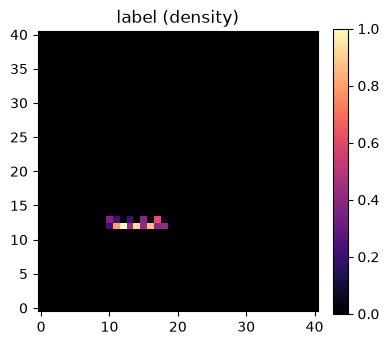

In [ ]:
label_2d = rasterize(
    stream_members_ra=detected["ra"].to_numpy(dtype=float),
    stream_members_dec=detected["dec"].to_numpy(dtype=float),
    stream_width_deg=stream_params.get("width", 0.0),
    params=stream_params,
    policy=label_cfg["policy"],
    window=window,
    pix=pix,
    dilate_to_width=label_cfg.get("dilate_to_width", False),
    normalization=label_cfg.get("normalization", "max"),
    smooth_sigma_deg=label_cfg.get("smooth_sigma_deg"),
)

fig, ax = plt.subplots(figsize=(4, 4))
im = ax.imshow(label_2d, origin="lower", cmap="magma")
ax.set_title(f"label ({label_cfg['policy']})")
plt.colorbar(im, ax=ax, fraction=0.046)
plt.show()

### 2.10 Assemble the `Sample`

Broadcasts the 2D label across every distance channel and bundles everything
`storage.SimulationStore` would persist.

In [ ]:
label_stack = np.broadcast_to(label_2d, (n_dist, *label_2d.shape)).astype(np.float32)

sample_manual = Sample(
    map_stack=map_stack,
    label_stack=label_stack,
    valid_mask=valid_mask,
    params=stream_params,
    metadata={"window": dataclasses.asdict(window), "distance_moduli": matched_filter_cfg["distance_moduli"]},
)
sample_manual

Sample(map_stack=array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]], shape=(3, 41, 41), dtype=float32), label_stack=array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0.,

## 3. The same thing, minimal command

Everything in §2.4-2.10 is exactly what `StreamInjector.inject_single_stream`
does internally, given the same `background`/`matched_filter` built in
§2.2-2.3 (reused here, not rebuilt — the matched filter must still only ever
touch the background once). One call, one `Sample`.

In [ ]:
injector = StreamInjector(
    background=background,
    matched_filter=matched_filter,
    stream_source=StreamObsSource(),
    cuts=cuts,
    clipping=clipping_cfg,
    pix=pix,
    survey=background_cfg["survey"],
    release=background_cfg["release"],
    bands=tuple(matched_filter_cfg["bands"]),
    richness_kind=richness_kind,
    label_policy=label_cfg["policy"],
    label_config=label_cfg,
    finalize_cfg=background_cfg["finalize"],
)

stream_params_raw = {k: v for k, v in stream_cfg.items() if k != "richness"}
stream_params_raw["richness"] = richness_value

sample_minimal = injector.inject_single_stream(stream_params_raw, np.random.default_rng(SEED))
sample_minimal

✓ Using cached survey data for 'lsst_yr1'


/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/streamml/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


Sample(map_stack=array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]], shape=(3, 41, 41), dtype=float32), label_stack=array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0.,

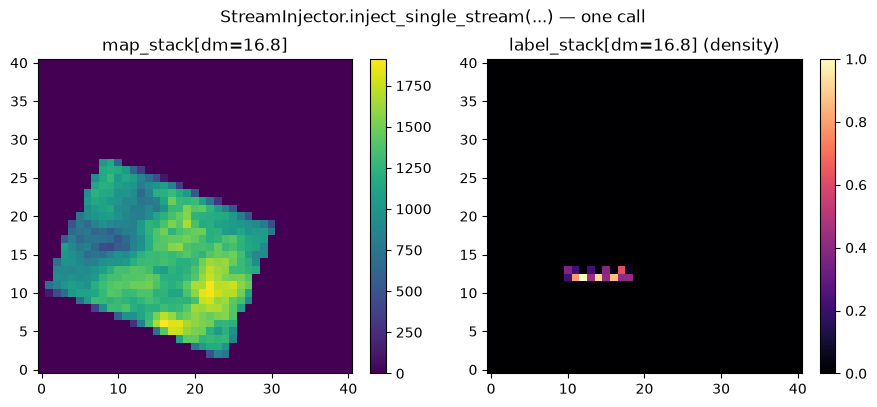

In [ ]:
# Pick whichever trial-distance channel is closest to the stream's own true
# distance_modulus, from matched_filter_cfg -- not a hardcoded index/value,
# so this stays correct if either config dict above changes.
dm_index = int(
    np.argmin(np.abs(np.array(matched_filter_cfg["distance_moduli"]) - stream_cfg["distance_modulus"]))
)
shown_dm = matched_filter_cfg["distance_moduli"][dm_index]

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
im0 = axes[0].imshow(sample_minimal.map_stack[dm_index], origin="lower", cmap="viridis")
axes[0].set_title(f"map_stack[dm={shown_dm}]")
plt.colorbar(im0, ax=axes[0], fraction=0.046)
im1 = axes[1].imshow(sample_minimal.label_stack[dm_index], origin="lower", cmap="magma")
axes[1].set_title(f"label_stack[dm={shown_dm}] ({label_cfg['policy']})")
plt.colorbar(im1, ax=axes[1], fraction=0.046)
fig.suptitle("StreamInjector.inject_single_stream(...) — one call")
plt.tight_layout()
plt.show()

### 3.1 Pure background (no stream)

For `background_fraction > 0` (decision 20) — no realization, no injection,
no rasterization, just the cached background cropped to a randomly placed
window.

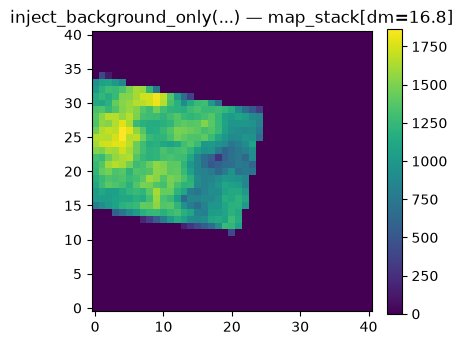

label_stack is all zero: True
params: {}


In [ ]:
window_bg_only = sample_random_window(
    background.footprint, pix.nside, size_deg=size_deg, rng=np.random.default_rng(SEED + 1)
)
sample_bg_only = inject_background_only(background, window_bg_only, pix)

fig, ax = plt.subplots(figsize=(4, 4))
im = ax.imshow(sample_bg_only.map_stack[dm_index], origin="lower", cmap="viridis")
ax.set_title(f"inject_background_only(...) — map_stack[dm={shown_dm}]")
plt.colorbar(im, ax=ax, fraction=0.046)
plt.show()

print("label_stack is all zero:", bool(np.all(sample_bg_only.label_stack == 0.0)))
print("params:", sample_bg_only.params)

## Summary

| Step-by-step (§2) | Minimal command (§3) |
|---|---|
| §2.4 `resolve_richness_to_nstars` + `StreamObsSource.realize` | `StreamInjector.inject_single_stream` step 1 |
| §2.5 `place_stream_in_footprint` | step 2 |
| §2.6 `ObsStreamInjector.inject` + `flag_col` filter + `apply_cuts`/`apply_magnitude_clipping` | steps 3-4 |
| §2.7 `sample_stream_window` | step 2 (window depends on placement, so it's sampled together with it) |
| §2.8 `select` + `make_raw_map` + `combine_full_maps` + `finalize_full` + `crop_window`, per distance | step 5-6 |
| §2.9 `rasterize` | step 7 |
| §2.10 `Sample(...)` | step 8 |

`Background.load_or_cache` (§2.3) is built once, outside the injector, and
handed in — that's what makes "the matched filter only ever touches the
background once, no matter how many streams get injected" true (verified in
`tests/test_injector.py::test_inject_single_stream_reuses_background_selection_across_injections`).